## All Packages needed

In [4]:
import torch
from torch import nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import os

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import scipy.ndimage
from scipy import misc
from glob import glob
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
import skimage
import imageio
import seaborn as sns
from PIL import Image
import glob
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

/tmp/ipykernel_1186251/91456258.py:14: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc


device(type='cuda')

# Data loading & inspection
## Getting shape of CSV file
## And summary of data types

In [5]:
#Getting a summary of the number of images and the different class IDs

df = pd.read_csv('labels_train.csv')
df.shape
df


,file_name,class_id
0,img_4358977458434011046.jpg,1
1,img_5224016757187192130.jpg,2
2,img_3065202206106254707.jpg,2
3,img_6304894865561547174.jpg,1
4,img_3371338542810939877.jpg,2
...,...,...
4667,img_6661311872293090412.jpg,2
4668,img_3844568579349757418.jpg,1
4669,img_9145812369383814369.jpg,1
4670,img_1311393330250392648.jpg,1


In [6]:
# Need to create folders for each X-ray type to store the images
types = df['class_id'].unique()
print(types)

[1 2 0]


# Feature-level analysis

## There are 3 image classes:

Class 0: no disease

Class 1: bacterial pneumonia

Class 2: viral pneumonia

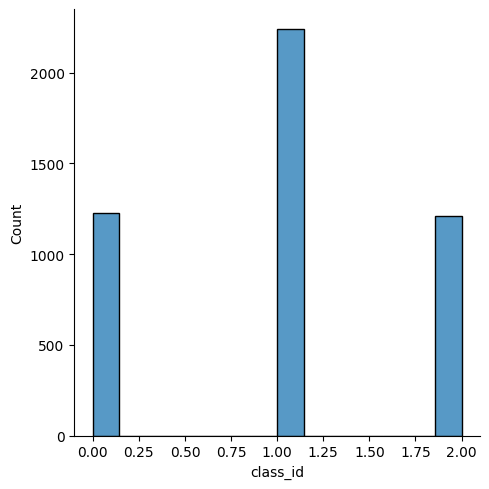

In [7]:
#visualization displot of the different classes and their image counts

sns.displot(df['class_id'])
plt.show()

## Discuss any class imbalance, possible bias, noise

There are many more bacterial image X-rays of pneumonia than there are normal and viral X-rays. We can fix this class imbalance with class weights.

## Missing values, outliers, duplicates

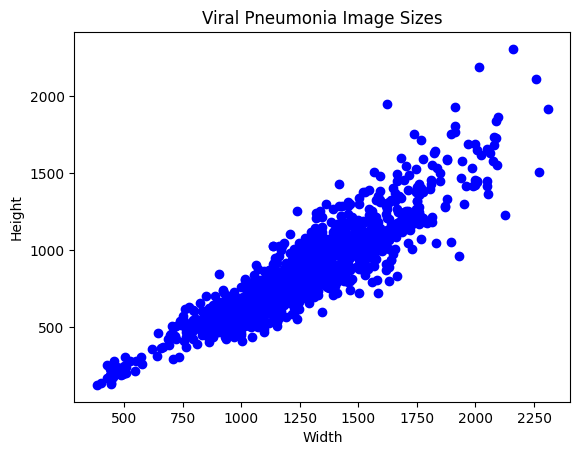

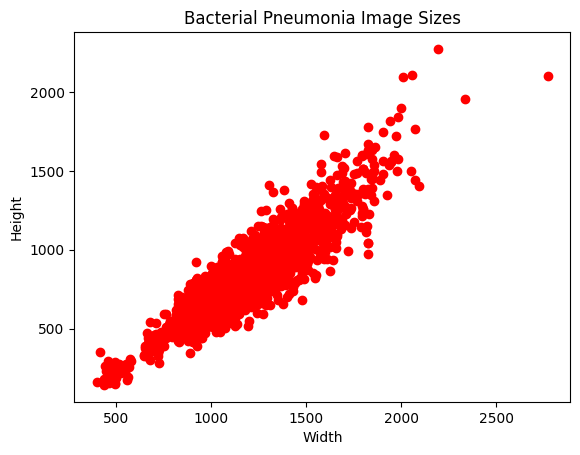

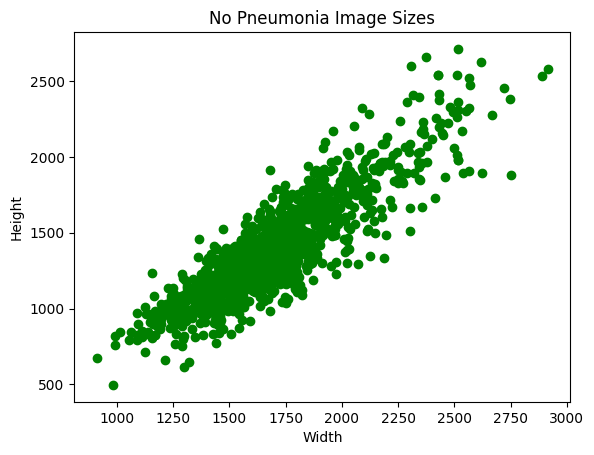

In [8]:
from PIL import Image
import os
import matplotlib.pyplot as plt

# Class folders inside final_train
base_dir = 'final_train'
classes = ['viral_pneumonia', 'bacterial_pneumonia', 'no_pneumonia']

vp_w, vp_h = [], []
bp_w, bp_h = [], []
np_w, np_h = [], []

for label in classes:
    folder_path = os.path.join(base_dir, label)
    
    for filename in os.listdir(folder_path):
        image_path = os.path.join(folder_path, filename)
        image = Image.open(image_path)
        w, h = image.size

        if label == 'viral_pneumonia':
            vp_w.append(w)
            vp_h.append(h)
        elif label == 'bacterial_pneumonia':
            bp_w.append(w)
            bp_h.append(h)
        else:
            np_w.append(w)
            np_h.append(h)

# Plot viral pneumonia sizes
plt.scatter(vp_w, vp_h, color='blue')
plt.xlabel('Width')
plt.ylabel('Height')
plt.title("Viral Pneumonia Image Sizes")
plt.show()

# Plot bacterial pneumonia sizes
plt.scatter(bp_w, bp_h, color='red')
plt.xlabel('Width')
plt.ylabel('Height')
plt.title("Bacterial Pneumonia Image Sizes")
plt.show()

# Plot no pneumonia sizes
plt.scatter(np_w, np_h, color='green')
plt.xlabel('Width')
plt.ylabel('Height')
plt.title("No Pneumonia Image Sizes")
plt.show()


In [7]:
#This shows if there are any missing values in the 2 columns provided with the CSV file
df.isnull().sum()

file_name    0
class_id     0
dtype: int64

## Calculating class weights

This is to compensate for the class imbalance seen with the histogram.

In [9]:
# sizes of each class
classes = df['class_id'].unique()
total_images = df.shape[0]
class_weights = {}
class_frequencies = []

for c in classes:
    class_weights[c] = df['class_id'].value_counts().get(c, 0)
    class_frequencies.append(class_weights[c]/total_images)
    class_weights[c] = class_weights[c]/total_images

class_median = np.median(class_frequencies)

for c in class_weights:
    class_weights[c] = class_median/class_weights[c]
    print(f"{c} : {class_weights[c]}")

1 : 0.5482573726541554
2 : 1.0165700082850042
0 : 1.0


## Placing the images in their respective folders

In [10]:
import os
import shutil

disease_types = df['class_id'].unique()
folders = {}
NP_count = 0
BP_count = 0
VP_count = 0


for type in disease_types:
    if type == 0:
        folder_name = 'final_train/no_pneumonia'
    elif type == 1:
        folder_name = 'final_train/bacterial_pneumonia'
    else:
        folder_name = 'final_train/viral_pneumonia'

    folders[type] = folder_name
    
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)
    else:
        print("already exisits")



#each image from the chest X-ray dataset

for filename in os.listdir('train_images/train_images'): 
    image = df.loc[df['file_name'] == filename]
    img_class = image['class_id'].values[0]
    src = 'train_images/train_images/' + filename
    
    if img_class == 0:
        folder = "final_train/no_pneumonia"
        file_count = NP_count
        NP_count += 1
    elif img_class == 1:
        folder = "final_train/bacterial_pneumonia"
        file_count = BP_count
        BP_count += 1
    else:
        folder = "final_train/viral_pneumonia"
        file_count = VP_count
        VP_count += 1

    
    dest = folder + '/' + filename
    shutil.copy(src, dest)

print("Done!")

for folder in folders.values():
    num_images = len(os.listdir(folder))
    print(f"{folder}: {num_images} total images")

already exisits
already exisits
already exisits


KeyboardInterrupt: 

In [12]:
import os


# Define the full paths to each folder inside 'final_train'
folders = {
    "no_pneumonia": "final_train/no_pneumonia",
    "bacterial_pneumonia": "final_train/bacterial_pneumonia",
    "viral_pneumonia": "final_train/viral_pneumonia"
}

for label, folder in folders.items():
    for filename in os.listdir(folder):
        if label == "no_pneumonia":
            file_count = NP_count
            NP_count += 1
        elif label == "bacterial_pneumonia":
            file_count = BP_count
            BP_count += 1
        else:
            file_count = VP_count
            VP_count += 1

        old_name = os.path.join(folder, filename)
        new_name = os.path.join(folder, f"{label}_{file_count}.jpg")

        os.rename(old_name, new_name)


# Visualization

Show examples in each folder

## For image data: grid samples

We are a little limited with what we can visualize as our metadata only has the image class id and what image it corresponds to


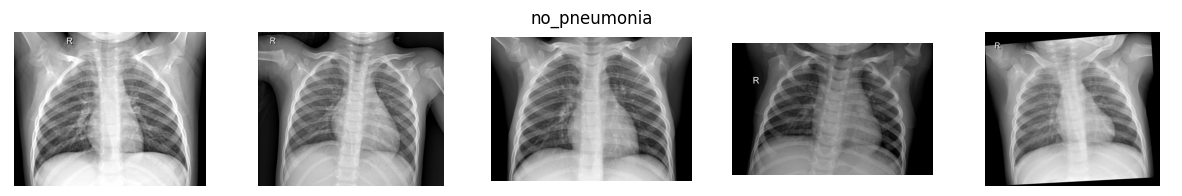

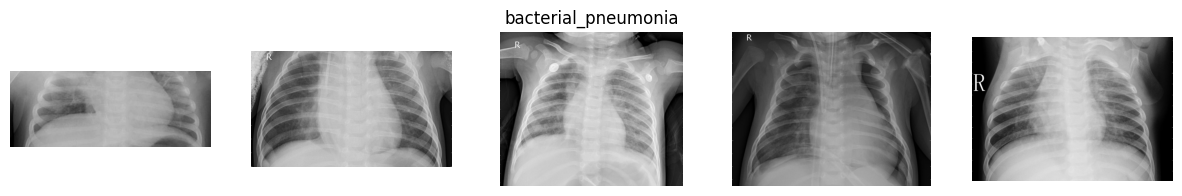

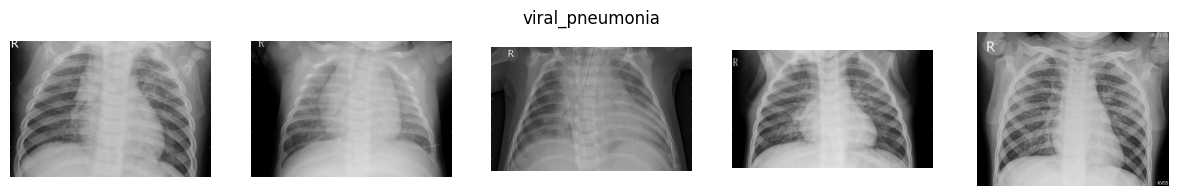

In [11]:
import os
import matplotlib.pyplot as plt

# Define the base directory
base_dir = 'final_train'

# Class folder names
classes = ['no_pneumonia', 'bacterial_pneumonia', 'viral_pneumonia']

for class_name in classes:
    folder_path = os.path.join(base_dir, class_name)
    
    plt.figure(figsize=(15, 2))
    plt.title(class_name)
    plt.axis('off')

    # Display 5 sample images from each class
    for i in range(5):
        img_path = os.path.join(folder_path, os.listdir(folder_path)[i])
        img = plt.imread(img_path)
        
        plt.subplot(1, 5, i + 1)
        plt.axis('off')
        plt.imshow(img, cmap="gray")
    
    plt.show()


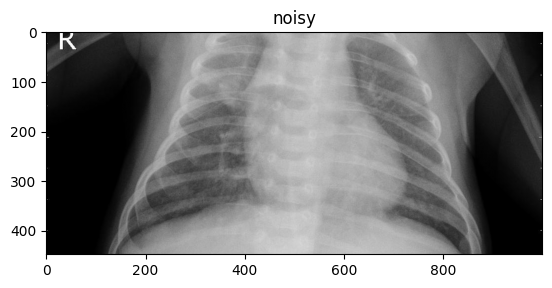

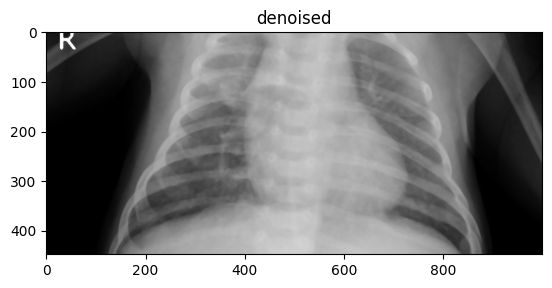

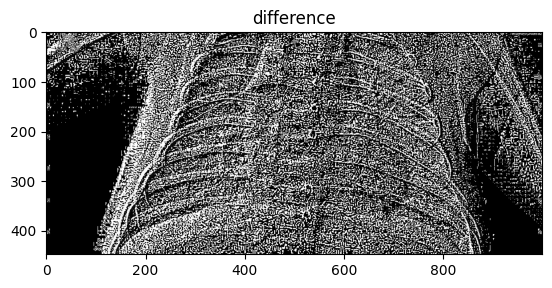

In [12]:
noisy_img = Image.open("final_train/viral_pneumonia/viral_pneumonia_100.jpg")
plt.title("noisy")
plt.imshow(noisy_img, cmap="gray")
plt.show()

filtered_img = scipy.ndimage.median_filter(noisy_img, size=6)
plt.title("denoised")
plt.imshow(filtered_img, cmap="gray")
plt.show()

diff_img = np.abs(filtered_img - noisy_img)
plt.title("difference")
plt.imshow(diff_img, cmap="gray")
plt.show()


## Preliminary plan for preprocessing
What needs fixing before modeling?

I believe the only thing left that needs fixing is the image size. Since images vary in size they will all needed to be transformed to the same size. We most likely will go with the proven 224x224 image size used in the skin lesion classification activity.

In [13]:
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from collections import Counter
from PIL import Image
import numpy as np
import cv2
import os

# === DEVICE ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Custom Preprocessing Function ===
class PreprocessXRAY:
    def __init__(self, output_size=(224, 224), mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], remove_artifacts=True):
        self.output_size = output_size
        self.mean = mean
        self.std = std
        self.remove_artifacts = remove_artifacts

    def __call__(self, pil_image):
        # Convert to grayscale numpy
        image = np.array(pil_image.convert("L"))

        # --- Artifact removal ---
        if self.remove_artifacts:
            _, binary = cv2.threshold(image, 5, 255, cv2.THRESH_BINARY)
            contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if contours:
                x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
                image = image[y:y+h, x:x+w]

        # --- Resize with padding (letterbox style) ---
        h, w = image.shape
        scale = self.output_size[0] / max(h, w)
        resized = cv2.resize(image, (int(w * scale), int(h * scale)))
        padded = np.full(self.output_size, 0, dtype=np.uint8)
        y_offset = (self.output_size[1] - resized.shape[0]) // 2
        x_offset = (self.output_size[0] - resized.shape[1]) // 2
        padded[y_offset:y_offset+resized.shape[0], x_offset:x_offset+resized.shape[1]] = resized

        # Convert to 3-channel PIL
        padded = np.stack([padded] * 3, axis=-1)  # Grayscale to 3 channels
        padded_pil = Image.fromarray(padded)

        # Apply tensor transform and normalize
        tensor_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=self.mean, std=self.std),
        ])
        return tensor_transform(padded_pil)


# === Instantiate custom transform ===
custom_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    PreprocessXRAY(remove_artifacts=True)  # <-- our custom class
])

# === Load Dataset ===
full_dataset = ImageFolder(root='final_train', transform=custom_transform)

# === Split Dataset ===
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size
generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size], generator=generator
)

# === DataLoaders ===
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# === Class Balance Check ===
def count_classes(subset, name):
    labels = [subset.dataset.samples[i][1] for i in subset.indices]
    counts = Counter(labels)
    print(f"\n{name} class distribution:")
    for class_idx, class_name in enumerate(subset.dataset.classes):
        print(f"Class {class_idx} ({class_name}): {counts[class_idx]}")

count_classes(train_dataset, "Train")
count_classes(val_dataset, "Validation")
count_classes(test_dataset, "Test")



Train class distribution:
Class 0 (bacterial_pneumonia): 2636
Class 1 (no_pneumonia): 1423
Class 2 (viral_pneumonia): 1465

Validation class distribution:
Class 0 (bacterial_pneumonia): 316
Class 1 (no_pneumonia): 208
Class 2 (viral_pneumonia): 166

Test class distribution:
Class 0 (bacterial_pneumonia): 349
Class 1 (no_pneumonia): 182
Class 2 (viral_pneumonia): 161


## ResNet Model:


In [14]:
from torch import nn
import torchvision.models as models
import torch

# Step 1: Load a pre-trained ResNet18 model
base_model = models.resnet18(pretrained=True)

# Step 2: Modify the model to add dropout and adjust the final fully connected layer
class ResNet18WithDropout(nn.Module):
    def __init__(self, model, dropout_rate=0.5, num_classes=3):
        super(ResNet18WithDropout, self).__init__()

        # Use all layers except the final fully connected layer
        self.backbone = nn.Sequential(*list(model.children())[:-1])
        
        # Dropout layer
        self.dropout = nn.Dropout(p=dropout_rate)
        
        # Final classification layer (512 is the output feature size from ResNet18)
        self.fc = nn.Linear(512, num_classes)
    
    def forward(self, x):
        # Pass through the convolutional layers
        x = self.backbone(x)

        # Flatten from (batch_size, 512, 1, 1) → (batch_size, 512)
        x = x.view(x.size(0), -1)
        
        # Apply dropout
        x = self.dropout(x)
        
        # Final classification layer
        x = self.fc(x)
        
        return x

# Create the model
model_with_dropout = ResNet18WithDropout(base_model, dropout_rate=0.5, num_classes=3)

# Move model to available GPU
print(torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

device = torch.device("cuda:1" if torch.cuda.device_count() > 1 else "cuda:0" if torch.cuda.is_available() else "cpu")
net = model_with_dropout.to(device)


/home/public/hrajanagan/myenv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/public/hrajanagan/myenv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


8
GPU 0: NVIDIA RTX 6000 Ada Generation
GPU 1: NVIDIA RTX 6000 Ada Generation
GPU 2: NVIDIA RTX 6000 Ada Generation
GPU 3: NVIDIA RTX 6000 Ada Generation
GPU 4: NVIDIA RTX 6000 Ada Generation
GPU 5: NVIDIA RTX 6000 Ada Generation
GPU 6: NVIDIA RTX 6000 Ada Generation
GPU 7: NVIDIA RTX 6000 Ada Generation


In [15]:
import torch
import torch.optim as optim

# Assuming class_weights is a dict like: {0: 1.0, 1: 2.5, ..., n: w}
# Convert it to a list or tensor in the correct order
weights_list = [class_weights[i] for i in range(len(class_weights))]
class_weights_tensor = torch.tensor(weights_list, dtype=torch.float).to(device)

# Now use it in the loss function
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(net.parameters(), lr=1e-6)
print(net)

ResNet18WithDropout(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runnin

In [16]:
from sklearn.metrics import accuracy_score

def get_accuracy(predicted, labels):
    batch_len, correct= 0, 0
    batch_len = labels.size(0)
    correct = (predicted == labels).sum().item()
    return batch_len, correct

def evaluate(model, val_loader):
    losses= 0
    num_samples_total=0
    correct_total=0
    model.eval()
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        out = model(inputs)
        _, predicted = torch.max(out, 1)
        loss = criterion(out, labels)
        losses += loss.item() 
        b_len, corr = get_accuracy(predicted, labels)
        num_samples_total +=b_len
        correct_total +=corr
    accuracy = correct_total/num_samples_total
    losses = losses/len(val_loader)
    return losses, accuracy

In [17]:
# number of loops over the dataset
num_epochs = 20
#set up arrays for accuracy
accuracy = []
val_accuracy = []
#set up arrays for losses
losses = []
val_losses = []

#training loop for the number of epocs specified
for epoch in range(num_epochs):
    #variable for monitoring training loss
    running_loss = 0.0
    #monitors for accuracy
    correct_total= 0.0
    num_samples_total=0.0
    #loop for iterating through training dataset
    for i, data in enumerate(train_loader):
        # get the inputs
        inputs, labels = data
        #move input data and labels to device (cuda/GPU or CPU)
        inputs, labels = inputs.to(device), labels.to(device)
        # set the parameter gradients to zero
        optimizer.zero_grad()
        
        # forward + backward + optimize
        outputs = net(inputs)
        #calculate loss
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        #compute accuracy
        _, predicted = torch.max(outputs, 1)
        #using get_accuracy function to count the correct predictions
        b_len, corr = get_accuracy(predicted, labels)
        num_samples_total +=b_len
        #calculating the total correct predictions
        correct_total +=corr
        #calculating the total training loss
        running_loss += loss.item()

    #getting running loss and training accuracy
    running_loss /= len(train_loader)
    train_accuracy = correct_total/num_samples_total
    val_loss, val_acc = evaluate(net, val_loader)
    
    #print epochs
    print('Epoch: %d' %(epoch+1))
    #print training loss and accuracy
    print('Loss: %.3f  Accuracy:%.3f' %(running_loss, train_accuracy))
    #print validating loss and accuracy
    print('Validation Loss: %.3f  Val Accuracy: %.3f' %(val_loss, val_acc))

    #add all these loss/accuracy measurments to their respective arrays for later use
    losses.append(running_loss)
    val_losses.append(val_loss)
    accuracy.append(train_accuracy)
    val_accuracy.append(val_acc)    
#print message to signify end of training loop
print('Finished Training')

Epoch: 1
Loss: 1.393  Accuracy:0.474
Validation Loss: 1.131  Val Accuracy: 0.629
Epoch: 2
Loss: 0.784  Accuracy:0.657
Validation Loss: 0.675  Val Accuracy: 0.722
Epoch: 3
Loss: 0.641  Accuracy:0.738
Validation Loss: 0.587  Val Accuracy: 0.774
Epoch: 4
Loss: 0.588  Accuracy:0.757
Validation Loss: 0.548  Val Accuracy: 0.787
Epoch: 5
Loss: 0.558  Accuracy:0.772
Validation Loss: 0.540  Val Accuracy: 0.788
Epoch: 6
Loss: 0.537  Accuracy:0.789
Validation Loss: 0.514  Val Accuracy: 0.800
Epoch: 7
Loss: 0.520  Accuracy:0.792
Validation Loss: 0.476  Val Accuracy: 0.826
Epoch: 8
Loss: 0.502  Accuracy:0.800
Validation Loss: 0.462  Val Accuracy: 0.829
Epoch: 9
Loss: 0.484  Accuracy:0.809
Validation Loss: 0.469  Val Accuracy: 0.816
Epoch: 10
Loss: 0.480  Accuracy:0.811
Validation Loss: 0.442  Val Accuracy: 0.841
Epoch: 11
Loss: 0.473  Accuracy:0.816
Validation Loss: 0.446  Val Accuracy: 0.829
Epoch: 12
Loss: 0.460  Accuracy:0.823
Validation Loss: 0.439  Val Accuracy: 0.822
Epoch: 13
Loss: 0.452  Ac

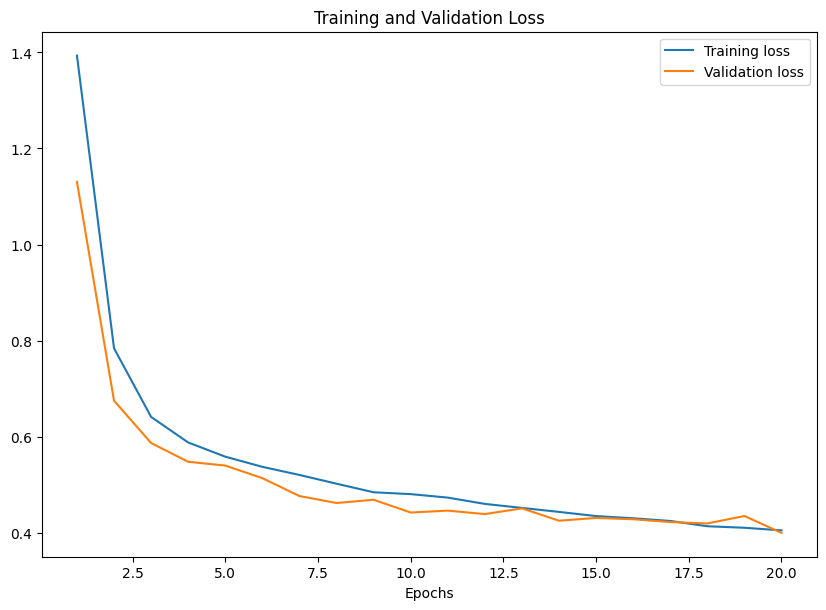

<Figure size 640x480 with 0 Axes>

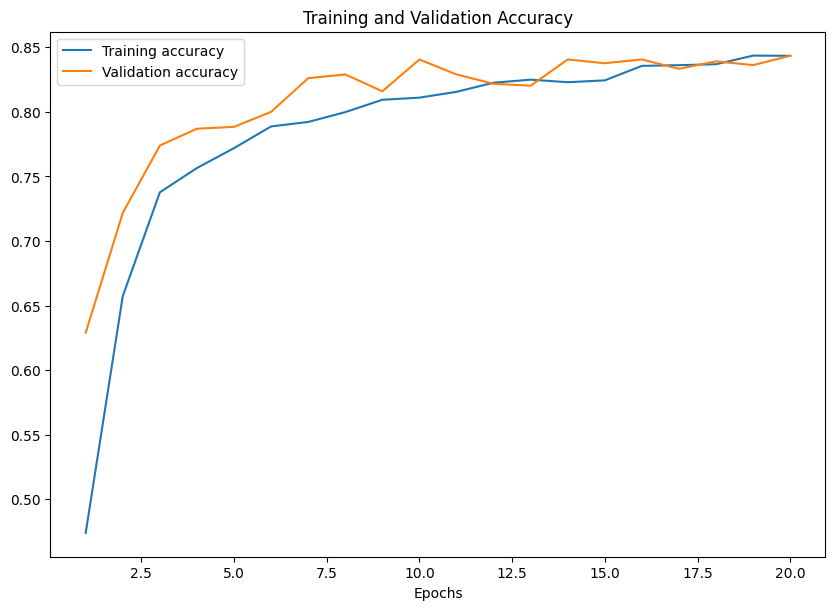

<Figure size 640x480 with 0 Axes>

In [18]:
# plt.plot(losses)
# plt.show()

#get epoch range for x axis of graph
epoch = range(1, num_epochs+1)
#set up a figure size 10x15 for our data
fig = plt.figure(figsize=(10, 15))
plt.subplot(2,1,2)
#plot measurements of training loss and validation loss
plt.plot(epoch, losses, label='Training loss')
plt.plot(epoch, val_losses, label='Validation loss')
#title for figure
plt.title('Training and Validation Loss')
#set epochs as x axis label
plt.xlabel('Epochs')
#create legend for different measurements
plt.legend()
plt.figure()
#show plot below notebook cell
plt.show()

#set up another figure
fig = plt.figure(figsize=(10, 15))
plt.subplot(2,1,2)
#plot both training accuracy and validation accuracy
plt.plot(epoch, accuracy, label='Training accuracy')
plt.plot(epoch, val_accuracy, label='Validation accuracy')
#set title
plt.title('Training and Validation Accuracy')
#set x axis title
plt.xlabel('Epochs')
#make legend for measurements
plt.legend()
plt.figure()
#show plot below cell
plt.show()

In [28]:
#variables for counting correct predictions
correct = 0
#total predictions
total = 0
net.eval()
with torch.no_grad():
    #loop for data in the test dataset
    for data in test_loader:
        images, labels = data
        #move input data and labels to device (cuda/GPU or CPU)
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
         #compute accuracy
        _, predicted = torch.max(outputs.data, 1)
        #get total number of labels
        total += labels.size(0)
        #add up correct predictions
        correct += (predicted == labels).sum().item()

#print accuracy
print('Accuracy of the network on the test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the test images: 81 %


In [29]:
#make two lists for tracking accuracy of each class
class_correct = list(0. for i in range(len(classes)))
class_total = list(1e-7 for i in range(len(classes)))
with torch.no_grad():
    #loop for data in the test data loader
    for data in test_loader:
        images, labels = data
        #move input data and labels to device (cuda/GPU or CPU)
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        #compute accuracy
        _, predicted = torch.max(outputs, 1)
        #using compare predicted with true label
        c = (predicted == labels).squeeze()
        #loop for adding to class correct and class total
        for i in range(3):
            label = labels[i]
            #adding to the correct predictions and total predictions for each class
            class_correct[label] += c[i].item()
            class_total[label] += 1

#printing the accuracy of each class
for i in range(len(classes)):
    print('Accuracy of %5s : %2d %%' % (
        #printing class and % out of 100
        classes[i], 100 * class_correct[i] / class_total[i]))

Accuracy of no_pneumonia : 91 %
Accuracy of bacterial_pneumonia : 88 %
Accuracy of viral_pneumonia : 58 %


In [30]:
#create confusion matric with size x and y of classes
confusion_matrix = torch.zeros(len(classes), len(classes))
with torch.no_grad():
    #loop for data in the test data loader
    for data in test_loader:
        images, labels = data
        #move input data and labels to device (cuda/GPU or CPU)
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        #get predicted for accuracy
        _, predicted = torch.max(outputs, 1)
        #updates confusion matrix based on if a predicted label is the same as the true label
        for t, p in zip(labels.view(-1), predicted.view(-1)):
                confusion_matrix[t.long(), p.long()] += 1

#output confusion matrix as data below code cell
print(confusion_matrix)
cm = confusion_matrix.numpy()

tensor([[313.,   4.,  32.],
        [ 13., 158.,  11.],
        [ 63.,   6.,  92.]])


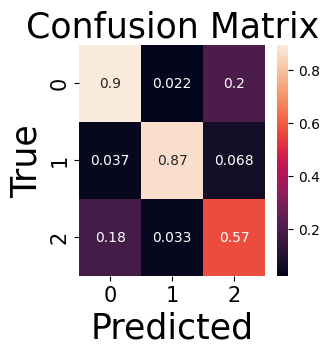

In [31]:
#set up figure to visually display data
fig,ax= plt.subplots(figsize=(3,3))
#create seaborn heatmap for visualizing confusion matrix
sns.heatmap(cm / (cm.astype(np.float64).sum(axis=1) + 1e-9), annot=True, ax=ax) #changed to float64

# labels, title and ticks
ax.set_xlabel('Predicted', size=25);
#setting x and y labels
ax.set_ylabel('True', size=25); 
#set title
ax.set_title('Confusion Matrix', size=25); 
#setting all labels for all classes in x and y axis
ax.xaxis.set_ticklabels(['0', '1', '2'], size=15); 
ax.yaxis.set_ticklabels(['0', '1', '2'], size=15);

plt.show() #added this

In [25]:
from collections import OrderedDict

class _BaseWrapper(object):
    """
    Please modify forward() and backward() according to your task.
    """

    def __init__(self, model):
        super(_BaseWrapper, self).__init__()
        self.device = next(model.parameters()).device
        self.model = model
        self.handlers = []  # a set of hook function handlers

    def _encode_one_hot(self, ids):
        one_hot = torch.zeros_like(self.logits).to(self.device)
        one_hot.scatter_(1, ids, 1.0)
        return one_hot

    def forward(self, image):
        """
        Simple classification
        """
        self.model.zero_grad()
        self.logits = self.model(image)
        self.probs = F.softmax(self.logits, dim=1)
        return self.probs.sort(dim=1, descending=True)

    def backward(self, ids):
        """
        Class-specific backpropagation
        Either way works:
        1. self.logits.backward(gradient=one_hot, retain_graph=True)
        2. (self.logits * one_hot).sum().backward(retain_graph=True)
        """

        one_hot = self._encode_one_hot(ids)
        self.logits.backward(gradient=one_hot, retain_graph=True)

    def generate(self):
        raise NotImplementedError

    def remove_hook(self):
        """
        Remove all the forward/backward hook functions
        """
        for handle in self.handlers:
            handle.remove()


class GradCAM(_BaseWrapper):
    """
    "Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization"
    https://arxiv.org/pdf/1610.02391.pdf
    Look at Figure 2 on page 4
    """

    def __init__(self, model, candidate_layers=None):
        super(GradCAM, self).__init__(model)
        self.fmap_pool = OrderedDict()
        self.grad_pool = OrderedDict()
        self.candidate_layers = candidate_layers  # list

        def forward_hook(key):
            def forward_hook_(module, input, output):
                # Save featuremaps
                self.fmap_pool[key] = output.detach()

            return forward_hook_

        def backward_hook(key):
            def backward_hook_(module, grad_in, grad_out):
                # Save the gradients correspond to the featuremaps
                self.grad_pool[key] = grad_out[0].detach()

            return backward_hook_

        # If any candidates are not specified, the hook is registered to all the layers.
        for name, module in self.model.named_modules():
            if self.candidate_layers is None or name in self.candidate_layers:
                self.handlers.append(module.register_forward_hook(forward_hook(name)))
                self.handlers.append(module.register_backward_hook(backward_hook(name)))

    def _find(self, pool, target_layer):
        if target_layer in pool.keys():
            return pool[target_layer]
        else:
            raise ValueError("Invalid layer name: {}".format(target_layer))

    def _compute_grad_weights(self, grads):
        return F.adaptive_avg_pool2d(grads, 1)

    def forward(self, image):
        self.image_shape = image.shape[2:]
        return super(GradCAM, self).forward(image)

    def generate(self, target_layer):
        fmaps = self._find(self.fmap_pool, target_layer)
        grads = self._find(self.grad_pool, target_layer)
        weights = self._compute_grad_weights(grads)

        gcam = torch.mul(fmaps, weights).sum(dim=1, keepdim=True)
        gcam = F.relu(gcam)

        gcam = F.interpolate(
            gcam, self.image_shape, mode="bilinear", align_corners=False
        )

        B, C, H, W = gcam.shape
        gcam = gcam.view(B, -1)
        gcam -= gcam.min(dim=1, keepdim=True)[0]
        gcam /= gcam.max(dim=1, keepdim=True)[0]
        gcam = gcam.view(B, C, H, W)

        return gcam
    
print(net)

ResNet18WithDropout(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runnin


True Class: bacterial_pneumonia
Generating Grad-CAM @backbone.7.1.bn2
	#0: bacterial_pneumonia (0.02041)


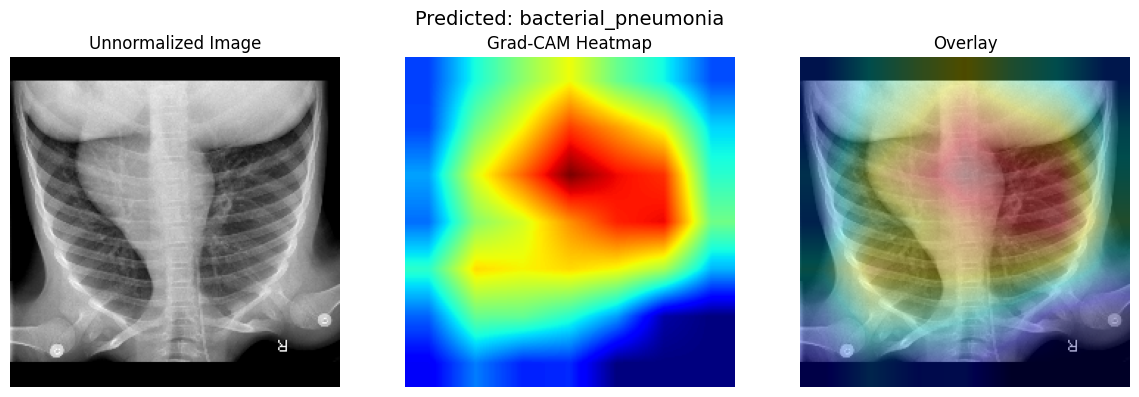


True Class: viral_pneumonia
Generating Grad-CAM @backbone.7.1.bn2
	#0: viral_pneumonia (0.00038)


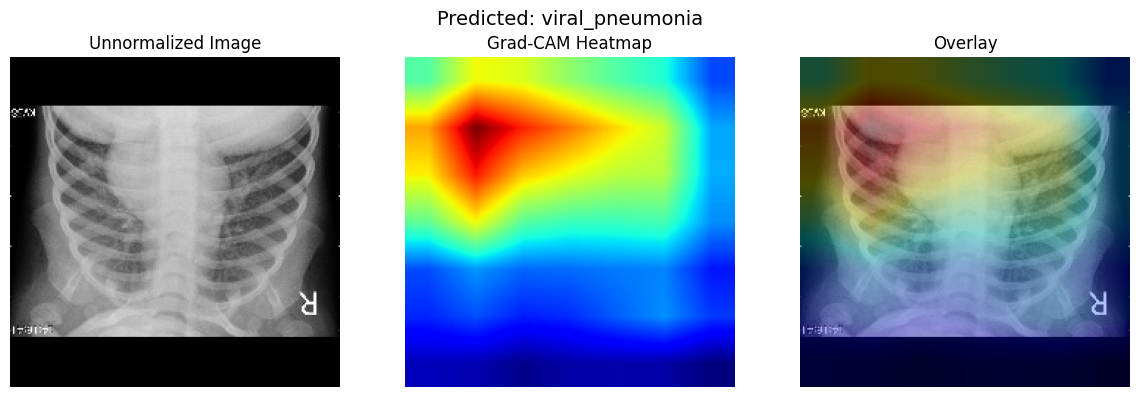


True Class: no_pneumonia
Generating Grad-CAM @backbone.7.1.bn2
	#0: no_pneumonia (0.73094)


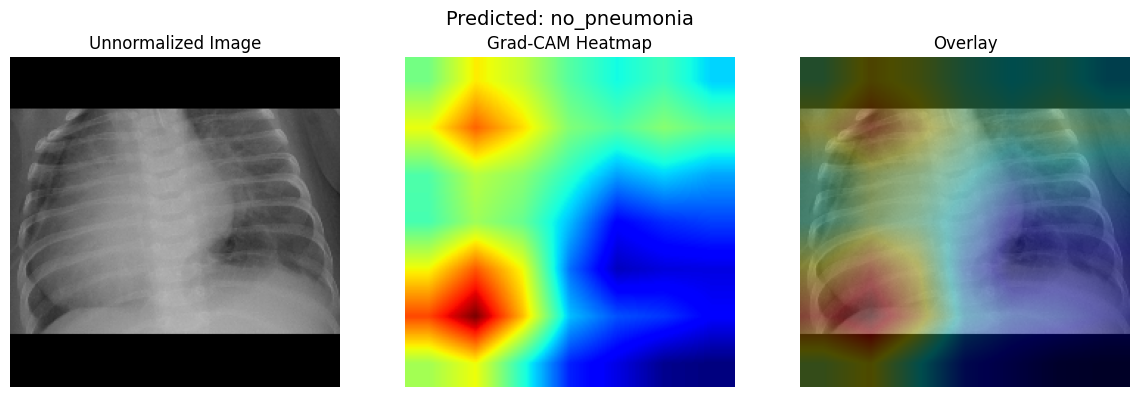

Generating Grad-CAM @backbone.7.1.bn2
	#0: bacterial_pneumonia (0.02041)


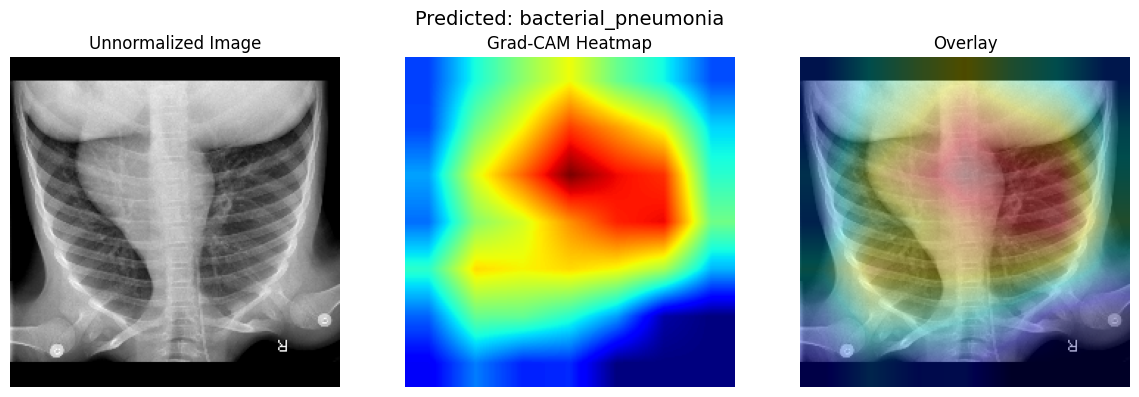

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


True Class:  bacterial_pneumonia


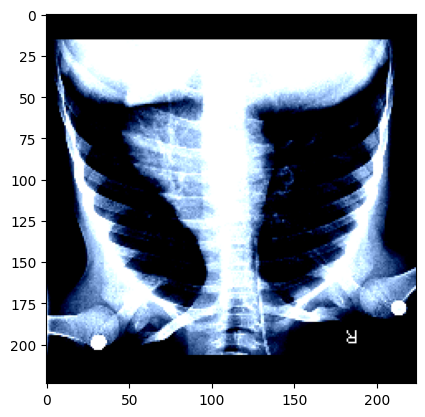

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..1.0000000236034394].


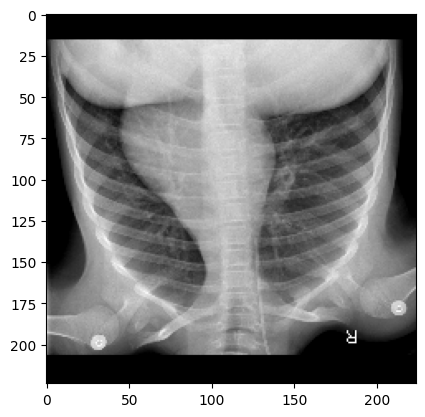

In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]


def demo2(image, label, model):
    """
    Generate Grad-CAM with overlay
    """
    model.to(device)
    model.eval()

    target_layers = ['backbone.7.1.bn2']
    target_class = label.item()

    images = image.unsqueeze(0)
    gcam = GradCAM(model=model)
    probs, ids = gcam.forward(images)
    ids_ = torch.LongTensor([[target_class]] * len(images)).to(device)
    gcam.backward(ids=ids_)

    for target_layer in target_layers:
        print("Generating Grad-CAM @{}".format(target_layer))
        regions = gcam.generate(target_layer=target_layer)

        for j in range(len(images)):
            print(
                "\t#{}: {} ({:.5f})".format(
                    j, classes[target_class], float(probs[0, target_class])
                )
            )

            # Grad-CAM heatmap
            gcam_region = regions[j, 0].cpu().numpy()
            gcam_resized = cv2.resize(gcam_region, (image.shape[2], image.shape[1]))
            heatmap = cv2.applyColorMap(np.uint8(255 * gcam_resized), cv2.COLORMAP_JET)
            heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

            # Unnormalize image
            image_np = image.cpu().numpy().transpose(1, 2, 0)
            image_unnorm = (image_np * np.array(norm_std)) + np.array(norm_mean)
            image_unnorm = np.clip(image_unnorm, 0, 1)

            # Convert to uint8
            image_uint8 = np.uint8(255 * image_unnorm)

            # Overlay
            overlay = cv2.addWeighted(image_uint8, 0.7, heatmap, 0.3, 0)

            # Show all
            plt.figure(figsize=(12, 4))

            plt.subplot(1, 3, 1)
            plt.imshow(image_unnorm)
            plt.title("Unnormalized Image")
            plt.axis("off")

            plt.subplot(1, 3, 2)
            plt.imshow(gcam_resized, cmap='jet')
            plt.title("Grad-CAM Heatmap")
            plt.axis("off")

            plt.subplot(1, 3, 3)
            plt.imshow(overlay)
            plt.title("Overlay")
            plt.axis("off")

            plt.suptitle(f"Predicted: {classes[target_class]}", fontsize=14)
            plt.tight_layout()
            plt.show()

# --- Run Grad-CAM for one image per class ---

# Track which classes we’ve seen
seen_classes = {cls: False for cls in range(len(classes))}

# Load the model
model = net

# Loop through validation data
for images, labels in val_loader:
    for i in range(len(labels)):
        label = labels[i].item()
        if not seen_classes[label]:
            print(f"\nTrue Class: {classes[label]}")
            image = images[i].to(device)
            label_tensor = labels[i].to(device)

            # Generate Grad-CAM visualization
            demo2(image, label_tensor, model)

            seen_classes[label] = True

    # Exit loop when we’ve visualized all classes
    if all(seen_classes.values()):
        break


image, label = next(iter(val_loader))
# Load the model
model = net
# Grad cam
demo2(image[0].to(device), label[0].to(device), model)


image = np.transpose(image[0], (1,2,0))
image2  = np.add(np.multiply(image.numpy(), np.array(norm_std)) ,np.array(norm_mean))
print("True Class: ", classes[label[0].cpu()])
plt.imshow(image)
plt.show()
plt.imshow(image2)
plt.show()

